# 02 , Analyse exploratoire (EDA)

On explore ici la base propre `flights` (~7 M de vols 2024) pour comprendre **quand** et **pour qui**
les retards arrivent. Ces observations guident le choix des features et l'interprétation du modèle.


In [1]:
import duckdb, pandas as pd, matplotlib.pyplot as plt
%matplotlib inline
db = duckdb.connect("../data/processed/flights.duckdb", read_only=True)
def q(sql): return db.execute(sql).df()

## 1. Distribution du retard à l'arrivée

On échantillonne 200 000 vols (assez pour la forme) et on borne à [-60, 180] min pour la lisibilité.

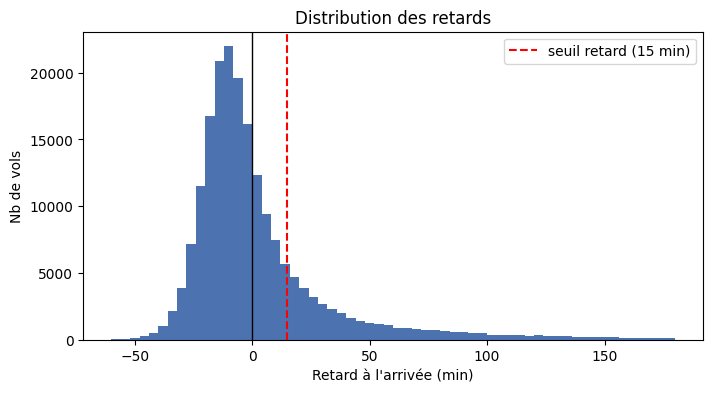

count    193847.0
mean          2.3
std          31.5
min         -60.0
25%         -15.0
50%          -6.0
75%           8.0
max         180.0
Name: arr_delay, dtype: float64

In [2]:
d = q("SELECT arr_delay FROM flights WHERE cancelled=0 AND arr_delay BETWEEN -60 AND 180 USING SAMPLE 200000")
plt.figure(figsize=(8,4))
plt.hist(d.arr_delay, bins=60, color="#4C72B0")
plt.axvline(0, color="k", lw=1); plt.axvline(15, color="red", ls="--", label="seuil retard (15 min)")
plt.xlabel("Retard à l'arrivée (min)"); plt.ylabel("Nb de vols"); plt.legend(); plt.title("Distribution des retards")
plt.show()
d.arr_delay.describe().round(1)

La distribution est **très asymétrique** : la majorité des vols sont à l'heure ou en avance
(médiane négative), mais une longue queue de gros retards tire la moyenne vers le haut. C'est
typique et justifie de traiter le problème en **classification** (>15 min ou non) plutôt qu'en
régression brute.

## 2. Taux de retard selon l'heure de départ prévue

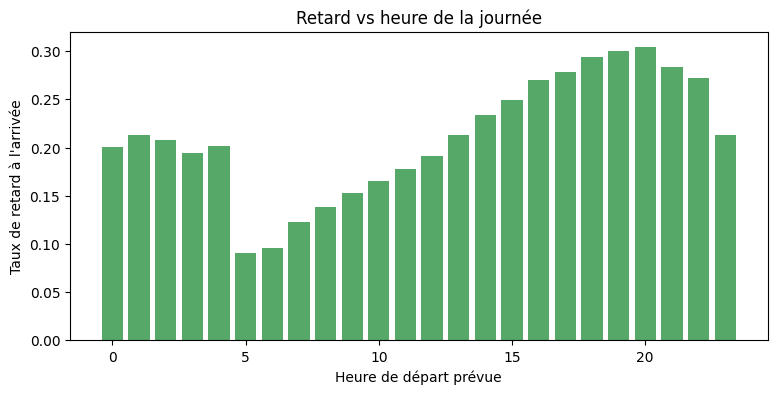

,dep_hour,taux,n
0,0,0.200198,12132
1,1,0.212697,4006
2,2,0.207809,1514
3,3,0.194574,1069
4,4,0.201521,526
5,5,0.090566,197520
6,6,0.095778,488754
7,7,0.122921,487952
8,8,0.138629,477222
9,9,0.152963,391494


In [3]:
h = q("SELECT dep_hour, avg(arr_del15) taux, count(*) n FROM flights WHERE cancelled=0 GROUP BY dep_hour ORDER BY dep_hour")
plt.figure(figsize=(9,4))
plt.bar(h.dep_hour, h.taux, color="#55A868")
plt.xlabel("Heure de départ prévue"); plt.ylabel("Taux de retard à l'arrivée"); plt.title("Retard vs heure de la journée")
plt.show()
h.head(24)

Effet net et attendu : les vols du **matin sont ponctuels**, puis le taux de retard **monte
tout au long de la journée** (les retards s'accumulent avec la rotation des avions). `dep_hour` sera
donc une feature forte.

## 3. Jour de la semaine et saisonnalité

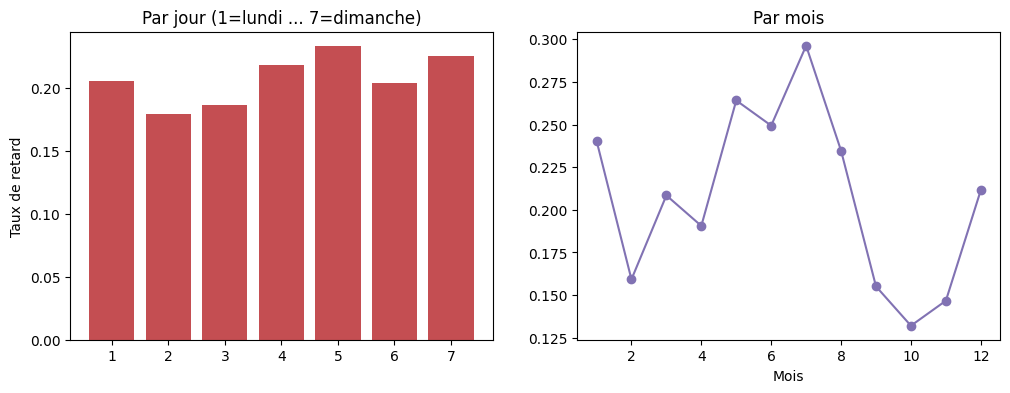

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))
w = q("SELECT day_of_week, avg(arr_del15) taux FROM flights WHERE cancelled=0 GROUP BY day_of_week ORDER BY day_of_week")
ax[0].bar(w.day_of_week, w.taux, color="#C44E52"); ax[0].set_title("Par jour (1=lundi ... 7=dimanche)"); ax[0].set_ylabel("Taux de retard")
m = q("SELECT month, avg(arr_del15) taux FROM flights WHERE cancelled=0 GROUP BY month ORDER BY month")
ax[1].plot(m.month, m.taux, "o-", color="#8172B3"); ax[1].set_title("Par mois"); ax[1].set_xlabel("Mois")
plt.show()

On voit une **saisonnalité** (mois d'été et d'hiver plus chargés/perturbés) et un effet
jour de semaine. `month` et `day_of_week` apportent donc de l'information.

## 4. Ponctualité par compagnie aérienne

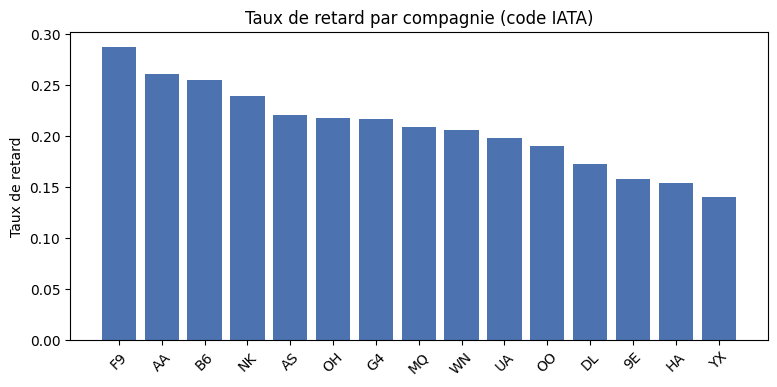

,airline,taux,n
0,F9,0.287401,203789
1,AA,0.261340,969054
2,B6,0.255093,236547
3,NK,0.239261,256105
4,AS,0.220720,241008
5,OH,0.217702,224220
6,G4,0.216718,115192
7,MQ,0.208603,275970
8,WN,0.206048,1407647
9,UA,0.198590,747973


In [5]:
c = q("SELECT airline, avg(arr_del15) taux, count(*) n FROM flights WHERE cancelled=0 GROUP BY airline HAVING n>50000 ORDER BY taux DESC")
plt.figure(figsize=(9,4))
plt.bar(c.airline, c.taux, color="#4C72B0")
plt.ylabel("Taux de retard"); plt.title("Taux de retard par compagnie (code IATA)"); plt.xticks(rotation=45)
plt.show()
c

Écart important entre compagnies (du simple au double) vers `airline` est discriminant.

## 5. Aéroports : volume vs retard

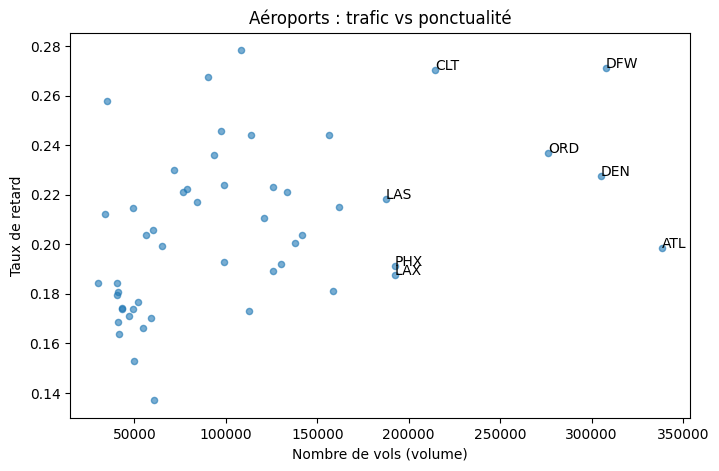

In [6]:
a = q("SELECT origin, avg(arr_del15) taux, count(*) n FROM flights WHERE cancelled=0 GROUP BY origin HAVING n>30000 ORDER BY n DESC")
plt.figure(figsize=(8,5))
plt.scatter(a.n, a.taux, s=20, alpha=0.6)
for _, r in a.head(8).iterrows(): plt.annotate(r.origin, (r.n, r.taux))
plt.xlabel("Nombre de vols (volume)"); plt.ylabel("Taux de retard"); plt.title("Aéroports : trafic vs ponctualité")
plt.show()

Les gros hubs ne sont pas tous égaux : certains combinent **fort trafic et forts retards**
(candidats naturels au clustering non supervisé du notebook 03).

## 6. Corrélations entre variables numériques

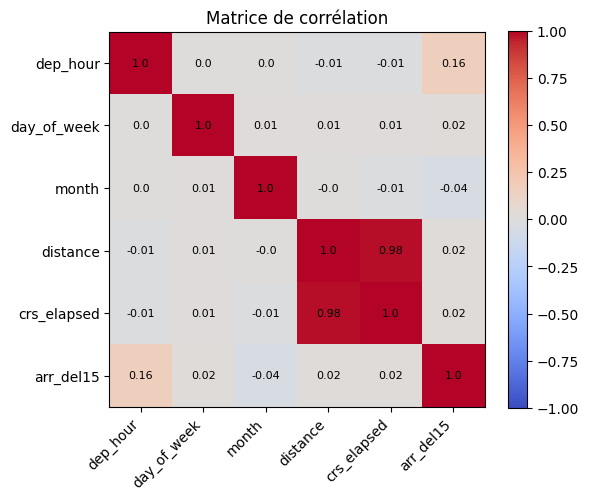

In [7]:
s = q("SELECT dep_hour, day_of_week, month, distance, crs_elapsed, arr_del15 FROM flights WHERE cancelled=0 USING SAMPLE 200000")
corr = s.corr(numeric_only=True).round(2)
plt.figure(figsize=(6,5))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.xticks(range(len(corr)), corr.columns, rotation=45, ha="right"); plt.yticks(range(len(corr)), corr.columns)
for i in range(len(corr)):
 for j in range(len(corr)): plt.text(j, i, corr.values[i,j], ha="center", va="center", fontsize=8)
plt.colorbar(); plt.title("Matrice de corrélation"); plt.tight_layout()
plt.show()

Les corrélations linéaires avec la cible sont **faibles** individuellement (`dep_hour` ressort
le plus) : aucune variable seule ne prédit le retard, il faut un modèle qui capte les **interactions**
(compagnie × aéroport × heure). C'est exactement le rôle du gradient boosting du notebook 03.